# **Lab4: Data Visualization**

**Course**: **INF-604: Data Analysis** <br>
**Lecturer**: **Sothea HAS, PhD**

-----

**Objective:** In this lab, you will apply the data visualization techniques you have studied to a real dataset. Each graph you create should be easy to understand and complete, including a title, legend, and other information to help the audience comprehend them easily. Effective graphs shouldn't take longer than 15 seconds for viewers to understand.

- Or you can work directly with `Google Colab` here: [Lab4_Data_Visualization.ipynb](https://colab.research.google.com/drive/1SJ0Ft43NerqXn5fXUhJY6vHOrom96dF1?usp=sharing).

-----


# 1. `Gapminder` dataset

[`Gapminder`](https://pypi.org/project/gapminder/) is an excerpt of data available at [https://gapminder.org](https://www.gapminder.org/). For each of $142$ countries (`country`), the package provides values for life expectancy (`lifeExp`), GDP per capita (`gdpPercap`), and population (`pop`), every five years, from $1952$ to $2007$ (`year`). It is initially used in [Jennifer Bryan's excellent `gapminder` teaching package for R](https://github.com/jennybc/gapminder/) ([`ggplot`](https://ggplot2.tidyverse.org/), [`tidyverse`](https://www.tidyverse.org/), and more). For more information about `gapminder`:

- Documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).

In [2]:

import numpy as np
import pandas as pd

%pip install gapminder  
from gapminder import gapminder as data
print(f"* Number of observations: {data.shape[0]}")
data.sample(3)

Note: you may need to restart the kernel to use updated packages.
* Number of observations: 1704



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,country,continent,year,lifeExp,pop,gdpPercap
1457,Swaziland,Africa,1977,52.537,551425,3781.410618
94,Bahrain,Asia,2002,74.795,656397,23403.559270
506,Ethiopia,Africa,1962,40.059,25145372,419.456416


----------

## **A. Variable types**

- Address dimension of the dataset.
- Which variables are considered quantitative and which are qualitative?
- Perform statistical summary on quantitative columns. Are there any missing values? Invalid data? Duplications? Outliers?
- Just take note if any problems above are detected but you don't need to handle them.

In [3]:
# Dimension
print(f"Data dimension: {data.shape}") # put f"Text {value}" to print Text with variable 'value'.

Data dimension: (1704, 6)


In [4]:
# Column type
print(f"Qualitative columns: {data.select_dtypes(include="object").columns.to_list()}")
print(f"Quantitative columns: {data.select_dtypes(include="number").columns.to_list()}")

Qualitative columns: ['country', 'continent']
Quantitative columns: ['year', 'lifeExp', 'pop', 'gdpPercap']


In [5]:
# Summary
data.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [6]:
data.isna().sum().to_frame().T

,country,continent,year,lifeExp,pop,gdpPercap
0,0,0,0,0,0,0


In [7]:
data.duplicated().sum()

np.int64(0)

The data has been preprocessed and has no missing values, no invalid data, no dupplications, but it has some outliers in columns: `pop` and `gdpPercap`.

<Axes: ylabel='lifeExp'>

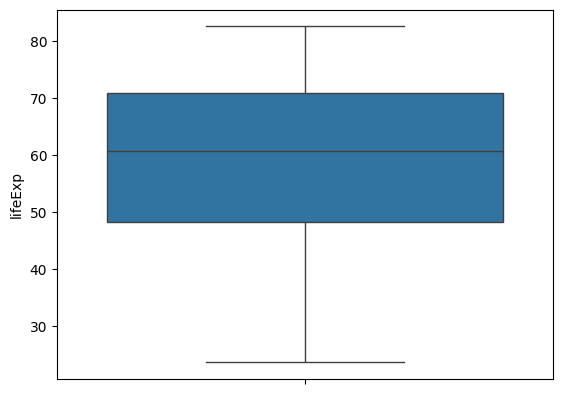

In [8]:
import seaborn as sns
sns.boxplot(
    data,
    y = 'lifeExp'
)

<Axes: ylabel='pop'>

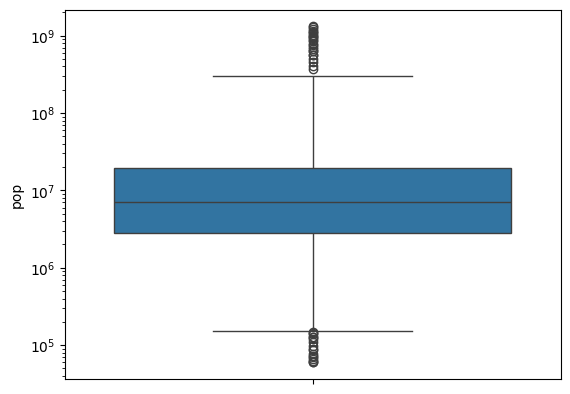

In [9]:
import seaborn as sns
sns.boxplot(
    data,
    y = 'pop',
    log_scale=True
)

<Axes: ylabel='gdpPercap'>

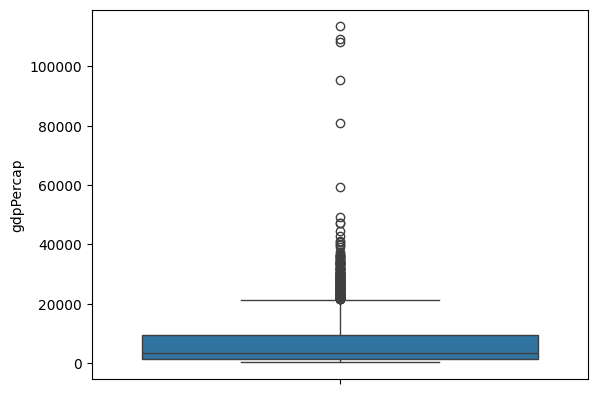

In [10]:
sns.boxplot(
    data,
    y = 'gdpPercap'
)

## **B. Year 1952**

### **B.1 Quantitative vs quantitative**

- Create a subdataset called `data1952` that contains only the information in year 1952.
- View relation between `gdpPercap` and `lifeExp` in 1952.
- View relation between `gdpPercap` and `pop` in 1952.
- View relation between `lifeExp` and `pop` in 1952.
- Do they look different from year 2007?

`Hint`: You can produce the same graphs as shown in the course using `Plotly` package avaialble here: [plotly python](https://plotly.com/python/).

In [11]:
data1952 = data.query("year == 1952") # query to filter all the rows with year == 1952.
data1952.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
12,Albania,Europe,1952,55.230,1282697,1601.056136
24,Algeria,Africa,1952,43.077,9279525,2449.008185
36,Angola,Africa,1952,30.015,4232095,3520.610273
48,Argentina,Americas,1952,62.485,17876956,5911.315053


In [12]:
import plotly.express as px 
# Create object plotly.express
fig = px.scatter(
    data1952,
    x = 'gdpPercap',
    y = 'lifeExp',
    color = 'continent',
    size = 'pop',
    size_max = 50,
    log_x = True
)

fig.update_layout(
    width = 600,
    title = 'GDP Per Capita vs Life Expectancy',
    height = 400
)
fig.show()


In [13]:
import plotly.express as px

# Create object plotly.express
fig = px.scatter(
    data1952,
    x = 'gdpPercap',
    y = 'pop',
    color = 'continent',
    size_max = 50,
    log_x = True,
    log_y = True
)

fig.update_layout(
    width = 600,
    title = 'GDP Per Capita vs Population',
    height = 400
)
fig.show()


In [14]:
fig = px.scatter(
    data1952,
    x = 'lifeExp',
    y = 'pop',
    color = 'continent',
    size_max = 50,
    log_y = True
)

fig.update_layout(
    width = 600,
    title = 'Life Expectancy vs Population',
    height = 400
)
fig.show()

In [15]:
import numpy as np

def corr_table(df):
    t = df.assign(log_gdpPercap=np.log10(df['gdpPercap']), log_pop=np.log10(df['pop']))
    return t[['lifeExp', 'log_gdpPercap', 'log_pop']].corr().round(2)

data2007 = data.query("year == 2007")
print("1952"); display(corr_table(data1952))
print("2007"); display(corr_table(data2007))

1952


,lifeExp,log_gdpPercap,log_pop
lifeExp,1.00,0.75,0.15
log_gdpPercap,0.75,1.00,0.01
log_pop,0.15,0.01,1.00


2007


,lifeExp,log_gdpPercap,log_pop
lifeExp,1.00,0.81,0.07
log_gdpPercap,0.81,1.00,-0.05
log_pop,0.07,-0.05,1.00


- According to the data, in 1952:
    - Which country was the richest?
    - Which country was the poorest?
    - Which country was the healthiest?
    - Which country was the unhealthiest?

In [16]:
data1952.query("gdpPercap == gdpPercap.max()") # select the row with gdpPercap == max(gdpPercap)

,country,continent,year,lifeExp,pop,gdpPercap
852,Kuwait,Asia,1952,55.565,160000,108382.3529


In [17]:
data1952.query("lifeExp == lifeExp.min()")

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314


In [18]:

data1952.query("lifeExp == lifeExp.max()").assign(title='Healthiest')


,country,continent,year,lifeExp,pop,gdpPercap,title
1140,Norway,Europe,1952,72.67,3327728,10095.42172,Healthiest


In [33]:

data1952.query("gdpPercap == gdpPercap.min()").assign(title='Poorest')

,country,continent,year,lifeExp,pop,gdpPercap,lifeExpQual,title
876,Lesotho,Africa,1952,42.138,748747,298.846212,moderate,Poorest


**Answers: 1952**

- **Richest**: Kuwait (\$108,382 per capita).
- **Poorest**: Lesotho (\$299 per capita).
- **Healthiest**: Norway (72.7 years).
- **Unhealthiest**: Afghanistan (28.8 years).

- Repeat the previous question for the year 1977. Before computing, can you guess which country had the lowest life expectancy around that year?

In [20]:
data1977 = data.query("year == 1977")
data1977.query("lifeExp == lifeExp.min()")

,country,continent,year,lifeExp,pop,gdpPercap
221,Cambodia,Asia,1977,31.22,6978607,524.972183


**Answer: lowest life expectancy in 1977**

- **Guess**: Cambodia.
- **Result**: Cambodia, 31.2 years.
- **Reason**: the Khmer Rouge regime (1975-1979).

### **B.2. Quatitative vs qualitative**

- We observed differences in health conditions across continents in 2007. Was this also the case in 1952? Please visualize your findings.
- What about the economy? Visualize and explain your results.

In [21]:
# Compute ordered names

ordered_cols = data1952.groupby('continent')['lifeExp'].mean().sort_values().index

fig_box = px.box(
    data1952,
    x = 'continent',
    y = 'lifeExp',
    color = 'continent',
    category_orders={'continent' : ordered_cols}
)
fig_box.update_layout(
    width = 600,
    height = 400,
    title = 'Life Expectancy across Continents in 1952'
)
fig_box.show()

In [22]:
data1952.groupby('continent')['lifeExp'].mean().sort_values().index

Index(['Africa', 'Asia', 'Americas', 'Europe', 'Oceania'], dtype='object', name='continent')

**Life expectancy across continents in 1952**

- Yes, continents differ a lot in 1952.
- Order (mean): Oceania (69.3) > Europe (64.4) > Americas (53.3) > Asia (46.3) > Africa (39.1).
- Same pattern as in 2007, but all values were lower.
- Oceania has only 2 countries, so abit hard to look at.

In [23]:
ordered_gdp = data1952.groupby('continent')['gdpPercap'].median().sort_values().index

fig_gdp = px.box(
    data1952,
    x = 'continent',
    y = 'gdpPercap',
    color = 'continent',
    log_y = True,
    category_orders = {'continent': ordered_gdp}
)
fig_gdp.update_layout(
    width = 600,
    height = 400,
    title = 'GDP per Capita across Continents in 1952 (log scale)'
)
fig_gdp.show()

**Economy across continents in 1952**

- Yes, continents also differ economically.
- Order (median GDP per capita): Oceania (\$10,298) > Europe (\$5,142) > Americas (\$3,048) > Asia (\$1,207) > Africa (\$987).
- Asia has a very high mean (\$5,195) but a low median (\$1,207).
- Reason: outlier Kuwait (\$108,382) inflates the mean.
- Richer continents also tend to be the healthier ones.

### **B.3. Qualitative vs qualitative**

Qualitative variables are simpler than quantitative ones, as we primarily focus on the proportion or frequency of each category. In our dataset, the existing qualitative variables are not suitable for analysis because they are repeated each year. Therefore, we will create a new qualitative `lifeExp`.

- Add to the data `data1952` a column `lifeExpQual` containing three categories: [**"unhealthy"**, **"moderate"**, **"healthy"**] by splitting `lifeExp` into 3 classes.

> Hint: you may cheat using [slide 15](https://hassothea.github.io/Data_Analysis_AUPP/Slides/Data_Visualization.html#/bivariate-visualization-8). The function `pd.qcut` is helpful for such a task.

- Graphically represent the connection between `lifeExpQual` and `continent` in year 1952.
- Describe what you see.

In [25]:
data1952['lifeExpQual'] = pd.qcut(
    data1952['lifeExp'],
    q=[0, 0.3333, 0.6666, 1],
    labels= ["unhealthy", "moderate", "healthy"]
)
data1952.head(3)

C:\Users\MSI\AppData\Local\Temp\ipykernel_30672\2427424150.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,country,continent,year,lifeExp,pop,gdpPercap,lifeExpQual
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,unhealthy
12,Albania,Europe,1952,55.230,1282697,1601.056136,healthy
24,Algeria,Africa,1952,43.077,9279525,2449.008185,moderate


In [26]:
# visualize the column: 'lifeExpQual' vs 'continent'

fig_qual = px.histogram(
    data1952,
    x = 'continent',
    color='lifeExpQual'
)
fig_qual.show()

In [27]:
pd.crosstab(data1952['continent'], data1952['lifeExpQual'])

lifeExpQual,unhealthy,moderate,healthy
continent,,,
Africa,34,18,0
Americas,2,13,10
Asia,11,14,8
Europe,0,2,28
Oceania,0,0,2


**Description: `lifeExpQual` vs `continent` (1952)**

- **Africa**: mostly unhealthy (34 of 52 countries), none healthy.
- **Europe**: almost all healthy (28 of 30).
- **Americas**: mostly moderate or healthy.
- **Asia**: mixed, with all three categories present.
- **Oceania**: both countries are healthy (only 2 countries).
- **Conclusion**: health level depends strongly on the continent.

## **C. Time evolution**

`Gapminder` captures global changes from $1952$ to $2007$. It is more insightful to examine how these variables evolve over time.

### **C.1. Evolution of average `lifeExp` of the $5$ continents**

1. Create a line plot of `lifeExp` for the five continents from $1952$ to $2007$ using `sns.lineplot`. What observations can you make from the plot?

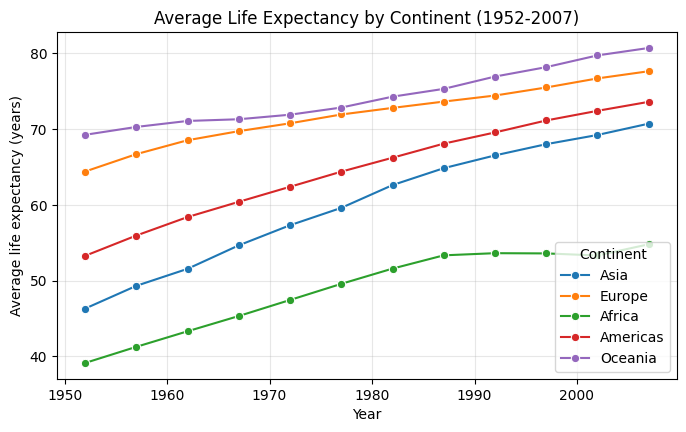

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=data, x='year', y='lifeExp', hue='continent', errorbar=None, marker='o')
plt.title('Average Life Expectancy by Continent (1952-2007)')
plt.xlabel('Year')
plt.ylabel('Average life expectancy (years)')
plt.legend(title='Continent')
plt.grid(alpha=0.3)
plt.show()

**Observations: `lifeExp`**

- All continents improve from 1952 to 2007.
- Oceania and Europe stay on top (about 80.7 and 77.6 years in 2007).
- Africa stays the lowest (39.1 to 54.8 years).
- Africa is almost flat from about 1990 to 2002.
- Asia improves the most (46.3 to 70.7 years, +24 years).
- The gap between continents shrinks, except for Africa.

### **C.2. Other variables**

- Repeat the same process with `pop`, and then with `gdpPercap`. Provide your comments for each case.

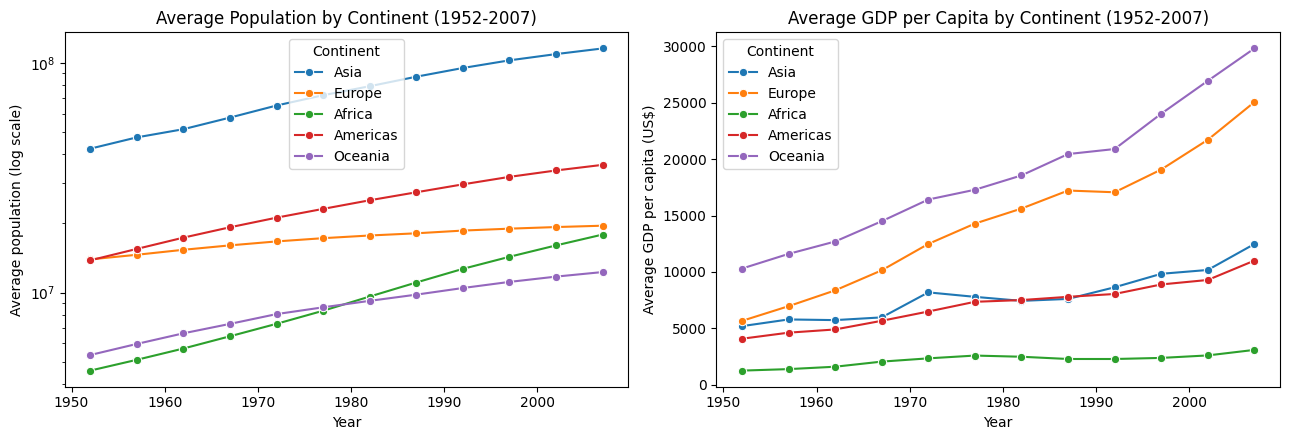

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Population (log scale because values differ a lot)
sns.lineplot(data=data, x='year', y='pop', hue='continent', errorbar=None, marker='o', ax=ax[0])
ax[0].set_yscale('log')
ax[0].set_title('Average Population by Continent (1952-2007)')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Average population (log scale)')
ax[0].legend(title='Continent')

# GDP per capita
sns.lineplot(data=data, x='year', y='gdpPercap', hue='continent', errorbar=None, marker='o', ax=ax[1])
ax[1].set_title('Average GDP per Capita by Continent (1952-2007)')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Average GDP per capita (US$)')
ax[1].legend(title='Continent')

plt.tight_layout()
plt.show()

 `pop`

- All continents grow over time.
- Asia has the highest average population (about 42M to 116M).
- Africa grows fastest in relative terms (about 4.6M to 17.9M).
- Europe and Oceania grow slowly.
- The log scale is used because population values differ a lot between continents.

 `gdpPercap`

- All continents are richer in 2007 than in 1952.
- Oceania and Europe are the richest and pull away from the others.
- Africa is nearly flat from 1977 to 2002 (about \$2,300-\$2,600).
- Asia grows strongly after 1990; its average is inflated by rich outliers such as Kuwait.
- The gap between rich and poor continents widens over time.

### **C.3. Cambodia**

- Plot the evolution of the three quantitative variables for **Cambodia**. What do you observe?

In [30]:
df_cam = data.query("country in ['Cambodia', 'Thailand']")
fig = px.line(df_cam, x='year', y='gdpPercap',
    symbol="country", color="country",
    title="Evolution of Life Expectancy")
fig.update_layout(height=350, width=600)
fig.show()

In [31]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cam = data.query("country == 'Cambodia'")

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Life Expectancy (years)", "Population", "GDP per Capita (US$)")
)
for i, col in enumerate(['lifeExp', 'pop', 'gdpPercap'], start=1):
    fig.add_trace(
        go.Scatter(x=cam['year'], y=cam[col], mode='lines+markers', name=col),
        row=1, col=i
    )
fig.update_xaxes(title_text="Year")
fig.update_layout(
    title="Cambodia (1952-2007): Evolution of the Three Quantitative Variables",
    height=380, width=1000, showlegend=False
)
fig.show()

**Cambodia: observations**

- **`lifeExp`**: rises from 39.4 (1952) to 45.4 (1967), then collapses to 31.2 in 1977 (lowest in the country's record).
- **Why the drop**: war and the Khmer Rouge regime (1975-1979).
- **Recovery**: jumps back to 51.0 in 1982, then grows slowly to 59.7 in 2007.
- **`pop`**: grows steadily from 4.7M to 14.1M, with a small dip in 1977.
- **`gdpPercap`**: stays very low (about \$370-\$730) from 1952 to 1997, with a small dip in 1972.
- **Growth in GDP**: takes off only after 1997, reaching about \$1,714 in 2007.
- **Overall**: Cambodia's shocks in the 1970s are visible in all three variables, but strongest in `lifeExp`.

# Further readings
- Gapminder documentation: [https://www.gapminder.org/data/documentation/](https://www.gapminder.org/data/documentation/)
- A short demonstration video is available here: [Hans Rosling's 200 Countries, 200 Years, 4 Minutes - The Joy of Stats - BBC Four](https://youtu.be/jbkSRLYSojo?si=qipg08VIi999hEgo).
- Graphical tools:
    - [`matplotlib`](https://matplotlib.org/stable/index.html)
    - [`seaborn`](https://seaborn.pydata.org/)
    - [`https://plotly.com/python/`](https://plotly.com/python/)